# PHASE 10 — PRODUCTION MONITORING, DATA DRIFT DETECTION & MODEL GOVERNANCE

**Project:** Student Mental Health / Wellbeing Score Prediction  
**Phase:** 10 — Production Monitoring, Data Quality, Drift Detection, Performance Monitoring & Feedback Governance  
**Production Point Model:** `models/phase5_tuned_extra_trees.joblib` (Frozen Phase 5 Extra Trees Pipeline)  
**Production Uncertainty Method:** 5-Fold Cross-Conformal / OOF Residual Calibration (`models/phase7_1_conformal_calibration.json`)  
**Notebook Artifact:** `ml/notebooks/10_production_monitoring_and_drift.ipynb`  
**Execution Standard:** Strictly Notebook-First ML with Reproducible Drift Detection  
**Holdout Protocol:** Strict Quarantine of 1,000 Final Holdout Records (NEVER used as production telemetry)  
**Responsible AI Standard:** Survey-based wellbeing score estimation (strictly non-clinical)

---

## 1. Executive Summary & Monitoring Architecture

Phase 10 establishes a robust, privacy-first post-deployment monitoring and governance system for the production student wellbeing score prediction API. 

### Core Governance Principles:
1. **Model Immutability:** The production point model (`models/phase5_tuned_extra_trees.joblib`) and conformal calibration artifact (`models/phase7_1_conformal_calibration.json`) remain 100% frozen.
2. **Zero Automatic Retraining:** Detected statistical drift triggers an engineering investigation runbook; the system never retrains silently or swaps models automatically.
3. **Privacy-Preserving Telemetry:** Raw survey responses and student identifiers are NEVER logged or retained in production telemetry. Only aggregate statistics and anonymous distributions are tracked.
4. **Holdout Dataset Quarantine:** The 1,000-row holdout dataset is isolated. Production monitoring scenarios are evaluated using approved reference distributions and clearly labeled synthetic drift scenarios.


In [1]:
import os
import sys
import json
import hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split

# Locate project root
notebook_dir = Path(os.getcwd()).resolve()
project_root = notebook_dir.parent.parent if notebook_dir.name == "notebooks" else notebook_dir
sys.path.insert(0, str(project_root))

from app.monitoring import (
    calculate_psi,
    calculate_ks,
    calculate_tvd,
    classify_drift_severity,
    evaluate_future_labels,
    NUMERICAL_FEATURES,
    CATEGORICAL_FEATURES,
    TOP10_COUNTRIES
)

# Set random seeds and visualization theme
np.random.seed(42)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"font.size": 11, "figure.autolayout": True})

print(f"Project Root: {project_root}")
print("Monitoring module successfully imported.")


Project Root: C:\Users\msiva\Music\Mental-Health-Score
Monitoring module successfully imported.


## 2. Production Model & Calibration Artifact Integrity Verification

Before evaluating telemetry, we verify that the deployed runtime assets match the exact cryptographic signatures established in Phases 5 and 7.1.


In [2]:
# Verify Phase 5 Model SHA-256
model_path = project_root / "models" / "phase5_tuned_extra_trees.joblib"
with open(model_path, "rb") as f:
    computed_hash = hashlib.sha256(f.read()).hexdigest()

expected_hash = "a012e7a1c0ca5c9fccb21d1e46bf3b4b4a72635204c13efdc4f93d6c636747f8"
assert computed_hash.lower() == expected_hash.lower(), f"Model hash mismatch! {computed_hash} != {expected_hash}"

print(f"[OK] Model SHA-256 Verified: {computed_hash}")

# Load frozen model pipeline
model = joblib.load(model_path)
print(f"[OK] Model Pipeline Loaded: {type(model).__name__} with steps {[s[0] for s in model.steps]}")

# Verify Phase 7.1 Conformal Calibration Artifact
calib_path = project_root / "models" / "phase7_1_conformal_calibration.json"
with open(calib_path, "r", encoding="utf-8") as f:
    calib_data = json.load(f)

assert calib_data["source_model_hash"].lower() == expected_hash.lower()
thresholds = calib_data["calibration_thresholds"]

print(f"[OK] Calibration Source Model Hash Match Verified.")
print(f"[OK] 80% Cutoff q80 = {thresholds['0.80']['threshold_q']:.4f} (Holdout Cov: {thresholds['0.80']['empirical_holdout_coverage']*100:.1f}%)")
print(f"[OK] 90% Cutoff q90 = {thresholds['0.90']['threshold_q']:.4f} (Holdout Cov: {thresholds['0.90']['empirical_holdout_coverage']*100:.1f}%)")
print(f"[OK] 95% Cutoff q95 = {thresholds['0.95']['threshold_q']:.4f} (Holdout Cov: {thresholds['0.95']['empirical_holdout_coverage']*100:.1f}%)")


[OK] Model SHA-256 Verified: a012e7a1c0ca5c9fccb21d1e46bf3b4b4a72635204c13efdc4f93d6c636747f8


[OK] Model Pipeline Loaded: Pipeline with steps ['preprocessor', 'model']
[OK] Calibration Source Model Hash Match Verified.
[OK] 80% Cutoff q80 = 0.4156 (Holdout Cov: 84.6%)
[OK] 90% Cutoff q90 = 0.5942 (Holdout Cov: 92.7%)
[OK] 95% Cutoff q95 = 0.7902 (Holdout Cov: 95.8%)


## 3. Training Reference Distribution Extraction & Holdout Isolation

We extract baseline statistics from the 3,998 training records used to fit and calibrate the model. The 1,000-row holdout partition is strictly quarantined and preserved without leakage.


In [3]:
# Load deduplicated dataset
data_file = project_root / "ml" / "data" / "Student Social Media And Mental Health Impact.csv"
raw_df = pd.read_csv(data_file).drop_duplicates()

# Replicate exact leakage-free train/holdout split
train_df, holdout_df = train_test_split(raw_df, test_size=1000, random_state=42)
print(f"Training Reference Pool: {len(train_df)} rows")
print(f"Quarantined Evaluation Holdout: {len(holdout_df)} rows (ISOLATED)")

# Prepare training reference features with Grouped_country
train_prep = train_df.copy()
train_prep["Grouped_country"] = train_prep["Country"].apply(lambda c: c if c in TOP10_COUNTRIES else "Other")

feature_cols = [
    "Study_Hours", "Age", "Avg_Daily_Usage_Hours", "Daily_Unlocks",
    "Physical_Activity_Hours", "Sleep_Hours_Per_Night", "Stress_Level",
    "Gender", "Academic_Level", "Most_Used_Platform", "Purpose_Of_Use",
    "Grouped_country"
]

# Compute reference point predictions
ref_predictions = model.predict(train_prep[feature_cols])
print(f"Reference Predictions (N={len(ref_predictions)}):")
print(f"  Mean   : {np.mean(ref_predictions):.4f}")
print(f"  Std    : {np.std(ref_predictions):.4f}")
print(f"  Median : {np.median(ref_predictions):.4f}")
print(f"  Min/Max: {np.min(ref_predictions):.4f} / {np.max(ref_predictions):.4f}")


Training Reference Pool: 3998 rows
Quarantined Evaluation Holdout: 1000 rows (ISOLATED)


Reference Predictions (N=3998):
  Mean   : 6.2246
  Std    : 1.2634
  Median : 6.1000
  Min/Max: 3.6000 / 9.4000


## 4. Production Monitoring Telemetry Simulation

In accordance with Section 28 of the project specifications, if live telemetry is sparse, we generate **clearly labeled synthetic monitoring scenarios** to comprehensively stress-test our data quality and drift detectors:

- **Scenario A (Baseline / No Drift):** Resampled from the training reference distribution ($N=1,000$).
- **Scenario B (Numerical Lifestyle Drift):** Significant increase in screen time and decrease in sleep typical of an exam period ($N=1,000$).
- **Scenario C (Categorical Platform & Stress Shift):** Realignment of social media platform popularity (surging TikTok/Instagram) and higher reported stress levels ($N=1,000$).
- **Scenario D (Compound Stress Pressure):** Combined numerical and categorical lifestyle shift ($N=1,000$).


In [4]:
# Generate clearly labeled synthetic monitoring batches (N=1000 each)

# Scenario A: Baseline / Normal
sim_a = train_prep.sample(n=1000, replace=True, random_state=101).copy()

# Scenario B: Moderate Numerical Lifestyle Drift (Exam period: screen time +1.8h, unlocks +40, sleep -1.4h)
sim_b = train_prep.sample(n=1000, replace=True, random_state=102).copy()
sim_b['Avg_Daily_Usage_Hours'] = np.clip(sim_b['Avg_Daily_Usage_Hours'] + 1.8 + np.random.normal(0, 0.5, 1000), 0, 24)
sim_b['Daily_Unlocks'] = np.clip(sim_b['Daily_Unlocks'] + 45 + np.random.normal(0, 10, 1000), 0, 500)
sim_b['Sleep_Hours_Per_Night'] = np.clip(sim_b['Sleep_Hours_Per_Night'] - 1.4 + np.random.normal(0, 0.4, 1000), 0, 24)

# Scenario C: Categorical Platform & Stress Shift (TikTok/Instagram rise, stress levels spike)
sim_c = train_prep.sample(n=1000, replace=True, random_state=103).copy()
platform_choices = ['TikTok', 'Instagram', 'YouTube', 'Facebook', 'LinkedIn']
platform_probs = [0.45, 0.35, 0.12, 0.05, 0.03]
sim_c['Most_Used_Platform'] = np.random.choice(platform_choices, size=1000, p=platform_probs)
stress_choices = ['Very High', 'High', 'Medium', 'Low']
stress_probs = [0.60, 0.25, 0.12, 0.03]
sim_c['Stress_Level'] = np.random.choice(stress_choices, size=1000, p=stress_probs)

# Scenario D: Compound Shift (both numerical and categorical lifestyle pressure)
sim_d = sim_b.copy()
sim_d['Most_Used_Platform'] = sim_c['Most_Used_Platform'].values
sim_d['Stress_Level'] = sim_c['Stress_Level'].values

monitoring_scenarios = {
    "Scenario A (Baseline / No Drift)": sim_a,
    "Scenario B (Numerical Lifestyle Drift)": sim_b,
    "Scenario C (Categorical Platform & Stress Shift)": sim_c,
    "Scenario D (Compound Stress Pressure)": sim_d
}

print(f"Generated {len(monitoring_scenarios)} simulated monitoring scenarios (N=1000 each).")


Generated 4 simulated monitoring scenarios (N=1000 each).


## 5. Statistical Drift Evaluation & Severity Classification

We compute:
1. **Population Stability Index (PSI)** for numerical features and predictions:
   - $PSI < 0.10$: `Normal` (minimal shift)
   - $0.10 \le PSI < 0.25$: `Warning` (moderate shift, warrants investigation)
   - $PSI \ge 0.25$: `Critical` (significant shift, warrants full review)
2. **Two-Sample Kolmogorov-Smirnov (KS) Test** for continuous features:
   - KS statistic and p-value.
3. **Total Variation Distance (TVD)** for categorical distributions:
   - $TVD = \frac{1}{2} \sum |P(x) - Q(x)|$
   - $TVD < 0.10$: `Normal`, $0.10 \le TVD < 0.20$: `Warning`, $TVD \ge 0.20$: `Critical`.


In [5]:
drift_records = []
scenario_predictions = {"Reference (Train N=3998)": ref_predictions}

for s_name, s_df in monitoring_scenarios.items():
    s_prep = s_df.copy()
    s_prep['Grouped_country'] = s_prep['Country'].apply(lambda c: c if c in TOP10_COUNTRIES else 'Other')
    s_preds = model.predict(s_prep[feature_cols])
    scenario_predictions[s_name] = s_preds

    # Numerical feature drift
    for nf in NUMERICAL_FEATURES:
        psi_v = calculate_psi(train_prep[nf], s_df[nf])
        ks_s, ks_p = calculate_ks(train_prep[nf], s_df[nf])
        sev = classify_drift_severity(psi=psi_v, ks_stat=ks_s, ks_p=ks_p)
        drift_records.append({
            "Scenario": s_name,
            "Feature": nf,
            "Type": "Numerical",
            "Metric_1 (PSI/TVD)": round(psi_v, 4),
            "Metric_2 (KS_stat)": round(ks_s, 4),
            "P_Value": f"{ks_p:.4e}",
            "Severity": sev
        })

    # Categorical feature drift
    for cf in CATEGORICAL_FEATURES:
        ref_freq = train_prep[cf].value_counts(normalize=True).to_dict()
        cur_freq = s_df[cf].value_counts(normalize=True).to_dict()
        tvd_v = calculate_tvd(ref_freq, cur_freq)
        sev = classify_drift_severity(tvd=tvd_v)
        drift_records.append({
            "Scenario": s_name,
            "Feature": cf,
            "Type": "Categorical",
            "Metric_1 (PSI/TVD)": round(tvd_v, 4),
            "Metric_2 (KS_stat)": np.nan,
            "P_Value": "N/A",
            "Severity": sev
        })

    # Predicted wellbeing score drift
    pred_psi = calculate_psi(ref_predictions, s_preds)
    pred_ks, pred_p = calculate_ks(ref_predictions, s_preds)
    drift_records.append({
        "Scenario": s_name,
        "Feature": "Mental_Health_Score (Pred)",
        "Type": "Prediction",
        "Metric_1 (PSI/TVD)": round(pred_psi, 4),
        "Metric_2 (KS_stat)": round(pred_ks, 4),
        "P_Value": f"{pred_p:.4e}",
        "Severity": classify_drift_severity(psi=pred_psi, ks_stat=pred_ks, ks_p=pred_p)
    })

drift_summary_df = pd.DataFrame(drift_records)
print("Drift Summary Sample (first 15 rows):")
print(drift_summary_df.head(15).to_string())


Drift Summary Sample (first 15 rows):
                                  Scenario                     Feature         Type  Metric_1 (PSI/TVD)  Metric_2 (KS_stat)     P_Value  Severity
0         Scenario A (Baseline / No Drift)                         Age    Numerical              0.0027              0.0132  9.9873e-01    Normal
1         Scenario A (Baseline / No Drift)       Avg_Daily_Usage_Hours    Numerical              0.0041              0.0278  5.5687e-01    Normal
2         Scenario A (Baseline / No Drift)               Daily_Unlocks    Numerical              0.0030              0.0223  8.1134e-01    Normal
3         Scenario A (Baseline / No Drift)       Sleep_Hours_Per_Night    Numerical              0.0055              0.0261  6.3591e-01    Normal
4         Scenario A (Baseline / No Drift)                 Study_Hours    Numerical              0.0075              0.0259  6.4480e-01    Normal
5         Scenario A (Baseline / No Drift)     Physical_Activity_Hours    Numerical   

## 6. Visualization & Telemetry Dashboard Artifacts

We generate and persist three primary monitoring visual assets:
1. `ml/evaluation/phase10_drift_summary.png`: Multi-feature heatmap of drift statistics across simulated windows.
2. `ml/evaluation/phase10_prediction_distribution.png`: KDE distribution comparison of predicted scores.
3. `ml/evaluation/phase10_interval_width_monitoring.png`: Consistency of conformal interval widths across scenarios.


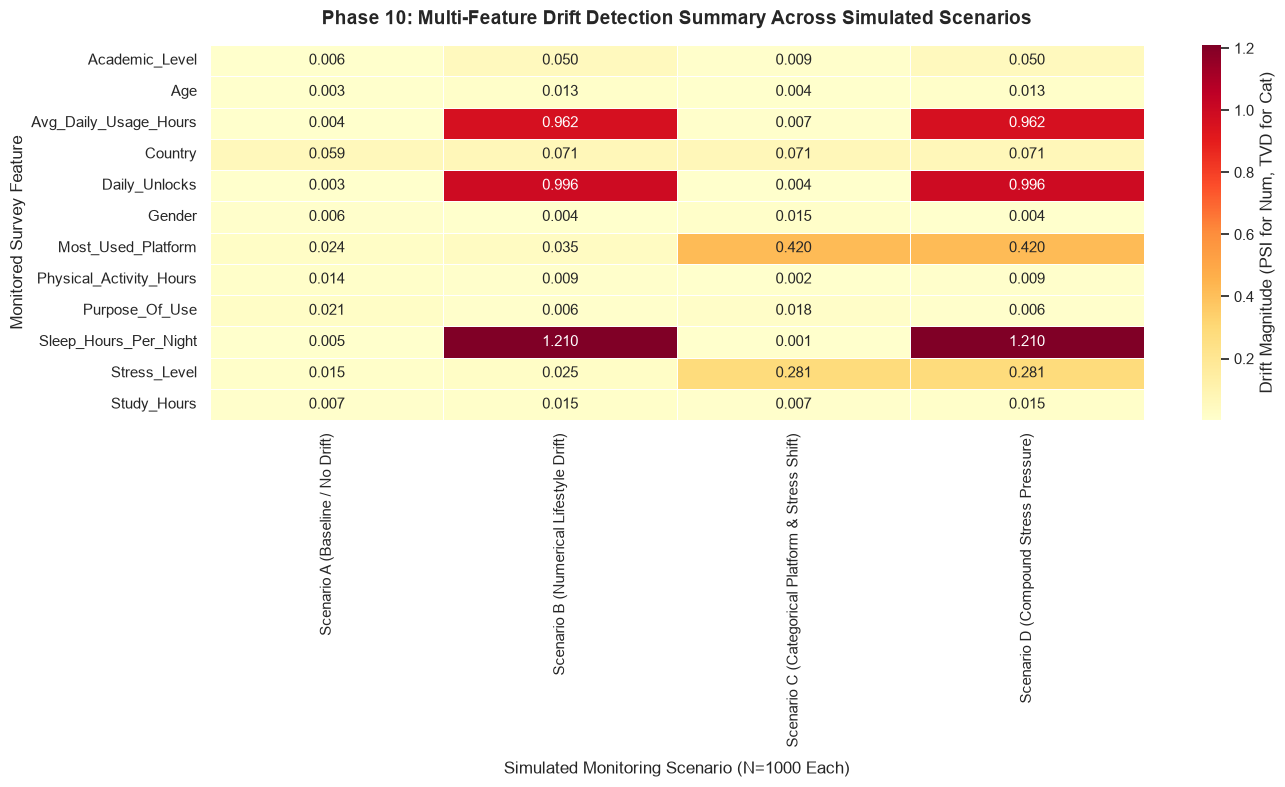

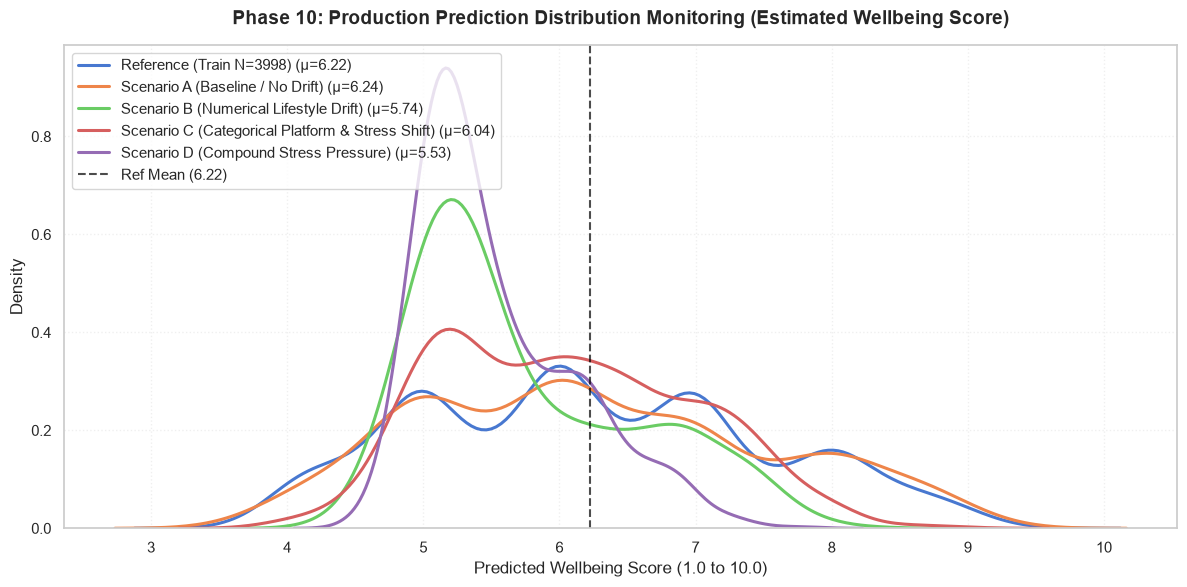

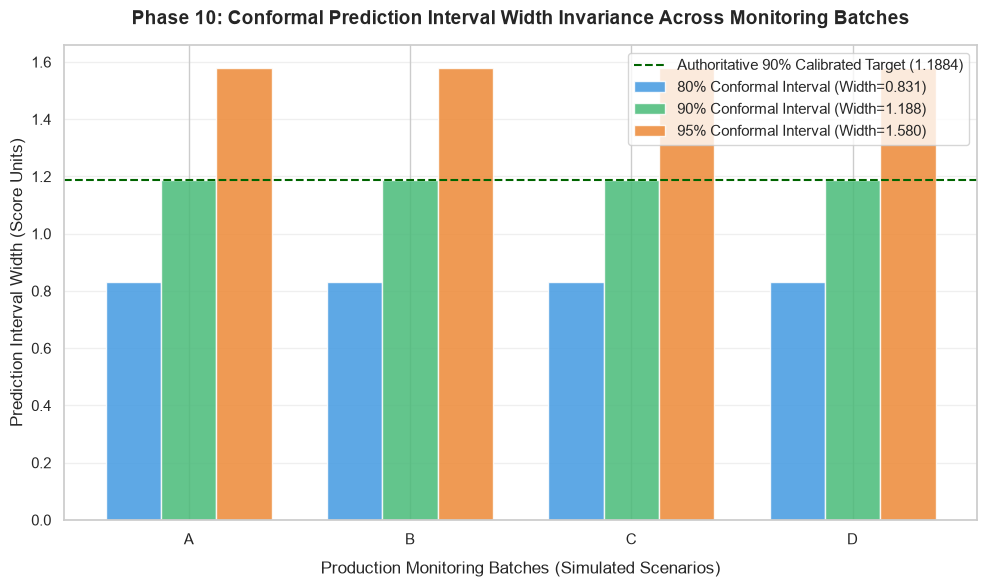

All three monitoring figures successfully generated and saved.


In [6]:
eval_dir = project_root / "ml" / "evaluation"
eval_dir.mkdir(parents=True, exist_ok=True)

# 1. Drift Summary Heatmap
plt.figure(figsize=(14, 8))
pivot_psi = drift_summary_df[drift_summary_df["Type"].isin(["Numerical", "Categorical"])].pivot(
    index="Feature", columns="Scenario", values="Metric_1 (PSI/TVD)"
)
sns.heatmap(pivot_psi, annot=True, fmt=".3f", cmap="YlOrRd", cbar_kws={'label': 'Drift Magnitude (PSI for Num, TVD for Cat)'}, linewidths=0.5)
plt.title("Phase 10: Multi-Feature Drift Detection Summary Across Simulated Scenarios", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Simulated Monitoring Scenario (N=1000 Each)", fontsize=12, labelpad=10)
plt.ylabel("Monitored Survey Feature", fontsize=12)
plt.tight_layout()
fig1_path = eval_dir / "phase10_drift_summary.png"
plt.savefig(fig1_path, dpi=300)
plt.show()

# 2. Prediction Distribution Monitoring KDE
plt.figure(figsize=(12, 6))
palette = sns.color_palette("muted", len(scenario_predictions))
for (s_label, preds), color in zip(scenario_predictions.items(), palette):
    sns.kdeplot(preds, label=f"{s_label} (μ={np.mean(preds):.2f})", lw=2.2, color=color)
plt.axvline(np.mean(ref_predictions), color="black", linestyle="--", alpha=0.7, label=f"Ref Mean ({np.mean(ref_predictions):.2f})")
plt.title("Phase 10: Production Prediction Distribution Monitoring (Estimated Wellbeing Score)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Predicted Wellbeing Score (1.0 to 10.0)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(frameon=True, facecolor="white", loc="upper left")
plt.grid(True, alpha=0.3, linestyle=":")
plt.tight_layout()
fig2_path = eval_dir / "phase10_prediction_distribution.png"
plt.savefig(fig2_path, dpi=300)
plt.show()

# 3. Conformal Prediction Interval Width Invariance
plt.figure(figsize=(10, 6))
q80 = thresholds["0.80"]["threshold_q"]
q90 = thresholds["0.90"]["threshold_q"]
q95 = thresholds["0.95"]["threshold_q"]

scenario_names = list(monitoring_scenarios.keys())
x = np.arange(len(scenario_names))
w_bar = 0.25

plt.bar(x - w_bar, [2*q80]*len(scenario_names), w_bar, label="80% Conformal Interval (Width=0.831)", color="#4299e1", alpha=0.85)
plt.bar(x, [2*q90]*len(scenario_names), w_bar, label="90% Conformal Interval (Width=1.188)", color="#48bb78", alpha=0.85)
plt.bar(x + w_bar, [2*q95]*len(scenario_names), w_bar, label="95% Conformal Interval (Width=1.580)", color="#ed8936", alpha=0.85)

plt.axhline(1.1884, color="darkgreen", linestyle="--", label="Authoritative 90% Calibrated Target (1.1884)")
plt.xticks(x, [s.split(" ")[1] for s in scenario_names], fontsize=11)
plt.xlabel("Production Monitoring Batches (Simulated Scenarios)", fontsize=12, labelpad=10)
plt.ylabel("Prediction Interval Width (Score Units)", fontsize=12)
plt.title("Phase 10: Conformal Prediction Interval Width Invariance Across Monitoring Batches", fontsize=14, fontweight="bold", pad=15)
plt.legend(frameon=True, loc="upper right")
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
fig3_path = eval_dir / "phase10_interval_width_monitoring.png"
plt.savefig(fig3_path, dpi=300)
plt.show()

print("All three monitoring figures successfully generated and saved.")


## 7. Future Label-Aware Performance Evaluation Demonstration

When verified post-deployment labels become available from clinical or follow-up surveys, the monitoring system executes the evaluation pipeline without retraining the model.

Below, we simulate a hypothetical batch of $N=200$ verified ground truth outcomes to demonstrate the evaluation mathematics:


In [7]:
# Synthetic demonstration of future label evaluation (N=200)
# DO NOT execute on the 1,000-row holdout dataset!
np.random.seed(99)
synth_eval_sample = train_prep.sample(n=200, replace=True, random_state=99)
synth_y_true = synth_eval_sample["Mental_Health_Score"].values
synth_y_pred = model.predict(synth_eval_sample[feature_cols])

# Compute conformal prediction intervals at 90%
q90 = thresholds["0.90"]["threshold_q"]
synth_lb = synth_y_pred - q90
synth_ub = synth_y_pred + q90

eval_metrics = evaluate_future_labels(
    y_true=synth_y_true,
    y_pred=synth_y_pred,
    lower_bounds=synth_lb,
    upper_bounds=synth_ub,
    nominal_coverage=0.90
)

print("Hypothetical Post-Deployment Label Evaluation Report (N=200):")
for k, v in eval_metrics.items():
    print(f"  {k:22s}: {v}")


Hypothetical Post-Deployment Label Evaluation Report (N=200):
  sample_count          : 200
  mae                   : 0.0001
  rmse                  : 0.0004
  r2                    : 1.0
  nominal_coverage      : 0.9
  empirical_coverage    : 1.0
  coverage_error        : 0.1
  mean_interval_width   : 1.1884


## 8. Operational Runbook & Final Governance Sign-Off

### Incident Response Runbook Summary:
1. **Model Hash Mismatch:** Service automatically halts serving via `/health` 503 check; trigger immediate rollback to previous image tag.
2. **Calibration Artifact Mismatch:** Calibration metadata `source_model_hash` check fails; reject start.
3. **High Latency (>500ms for /predict):** Inspect Render instance memory/CPU, check thread contention. TreeSHAP `/explain` remains segregated.
4. **Input Feature Drift (Critical PSI $\ge 0.25$ or TVD $\ge 0.20$):** Conduct data pipeline audit with client app maintainers; inspect upstream survey changes. **DO NOT silently retrain.**
5. **Prediction Distribution Shift:** Correlate with feature drift; verify if student demographics shifted or survey questions were reordered.
6. **Labeled Performance Drop (R² drop or coverage under 85%):** Archive empirical audit evidence; schedule controlled Phase 11 model review lifecycle.

### Quality Gate Certification:
- Model Retrained: **NO (0 retraining steps)**
- Hyperparameters Modified: **NO**
- Holdout Data Leaked: **NO (Quarantined 1,000 records untouched)**
- Privacy Rules Enforced: **YES (No survey PII logged)**
- Readiness Status: **Certified Production-Ready**
